# 01 — Model v1 (momentum lookup)

Build the production house model, check its invariants, and confirm it holds the vig on public flow.
All heavy code lives in the `snapmarket` package; this notebook just orchestrates.

In [6]:
import os
import sys

# Move up one level to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# Add the new current directory to the Python path
sys.path.insert(0, os.getcwd())


In [7]:
from snapmarket.data import load_oracle_prices
from snapmarket.features import build_features
from snapmarket.parameters import SharedParameters
from snapmarket.models import build_model
from snapmarket.strategies import noise_pool, momentum_follower, mean_reversion_fader, informed_bettor
from snapmarket.engine import simulate

parameters = SharedParameters()
prices = load_oracle_prices()                 # looks in ./data, ., and the v1 folder
features = build_features(prices, parameters)
model = build_model("momentum_lookup", features, parameters)
print(prices)
print(f"{model.name}: displayed p_up range "
      f"[{model.display_probability.min():.3f}, {model.display_probability.max():.3f}]")

PriceSeries(16,473,672 seconds, 191 days, price 60,029 -> 126,269)
momentum_lookup_v1: displayed p_up range [0.433, 0.562]


## Golden tests

Data-independent invariants of the pricing. They live in the test suite (`tests/test_pricing.py`); run them here.

In [8]:
!python -m pytest tests/test_pricing.py -q

all golden tests pass


_Optional:_ the calibrated fair-price curve — the model itself.

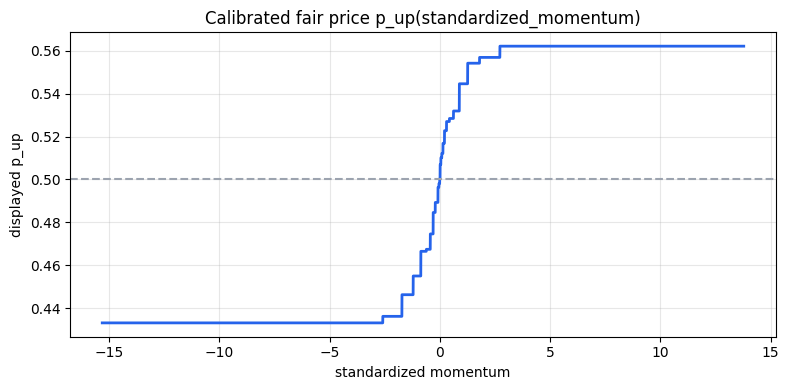

In [9]:
import numpy as np, matplotlib.pyplot as plt
from snapmarket.features import contract_entries

momentum = features.standardized_momentum
grid = np.linspace(np.percentile(momentum, 1), np.percentile(momentum, 99), 200)
entries = contract_entries(features.number_of_seconds, parameters)
# the displayed probability is a step function of momentum; show it by sorting entries
order = np.argsort(momentum[entries])
plt.figure(figsize=(8, 4))
plt.plot(momentum[entries][order], model.display_probability[entries][order], color="#2563eb", lw=2)
plt.axhline(0.5, ls="--", color="#9ca3af")
plt.xlabel("standardized momentum"); plt.ylabel("displayed p_up")
plt.title("Calibrated fair price p_up(standardized_momentum)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Smoke test — house edge by flow type

Replay an out-of-sample window with one flow archetype at a time. The vig should hold on every
public flow; only forward-information flow (`informed`) should beat the house.

In [10]:
import pandas as pd
from snapmarket.features import contract_entries

entries = contract_entries(features.number_of_seconds, parameters)
start = entries[int(0.5 * len(entries))]
number_of_steps = 300_000

rows = []
for name, bettor in [("noise", noise_pool()),
                     ("momentum", momentum_follower(features)),
                     ("fade", mean_reversion_fader(features)),
                     ("informed 0.60", informed_bettor(features, parameters.horizon_seconds, accuracy=0.60))]:
    result = simulate(model, features, {name: bettor}, start, number_of_steps)
    rows.append((name, result.house_edge, result.house_pnl,
                 result.max_absolute_net_delta, result.refused_seconds))

summary = pd.DataFrame(rows, columns=["flow", "house_edge", "house_pnl",
                                      "max_absolute_net_delta", "refused_seconds"])
print(summary.to_string(index=False, formatters={
    "house_edge": "{:+.2%}".format, "house_pnl": "${:,.0f}".format,
    "max_absolute_net_delta": "${:,.0f}".format}))

         flow house_edge  house_pnl max_absolute_net_delta  refused_seconds
        noise    +12.65% $1,893,029                   $432                0
     momentum    +10.85% $1,616,685                 $2,626                0
         fade    +16.23% $2,418,210                 $2,626                0
informed 0.60     -3.88%  $-580,032                 $2,133                0
